# Exploratory Data Analysis (EDA) - Superstore Dataset

## Day 2 Internship Task

This notebook performs exploratory data analysis on the cleaned Superstore dataset.

The objective is to understand the structure of the dataset, summarize the data statistically, identify patterns and relationships, investigate potential outliers, and communicate important findings using visualizations.

In [1]:
# I am importing the libraries required for data analysis and visualization.
# Pandas will help me work with the dataset.
# NumPy will support numerical operations.
# Matplotlib and Seaborn will help me create visualizations.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# I am setting a clean visualization style so that my charts
# are easier to read and compare during the analysis.

sns.set_theme(style="whitegrid")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_superstore.csv to cleaned_superstore.csv


In [4]:
# I am loading the cleaned Superstore dataset into a Pandas DataFrame.
# I am using the cleaned version because the data-quality checks
# were already completed during Day 1.

df = pd.read_csv('cleaned_superstore.csv')

In [5]:
df

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9972,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9973,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9974,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9975,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [6]:
# I am viewing the first few rows to make sure that
# the dataset has been loaded correctly and the columns
# contain the expected type of information.

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [7]:
# I am checking the last few records as an additional
# confirmation that the complete file has been loaded.

df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9972,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9973,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9974,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9975,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9976,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [8]:
# I am checking the shape of the dataset to understand
# how many rows and columns are available for analysis.

df.shape

(9977, 13)

In [9]:
# I am checking the column names so I know which variables
# are available for my analysis and visualization.

df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [10]:
# I am checking the data types of each column.
# This helps me understand which columns are numerical
# and which columns contain categories or text.

df.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,int64
Region,object
Category,object
Sub-Category,object
Sales,float64


In [11]:
# I am using info() to get a compact overview of the dataset,
# including the number of rows, columns, data types,
# and non-null values.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9977 entries, 0 to 9976
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   object 
 1   Segment       9977 non-null   object 
 2   Country       9977 non-null   object 
 3   City          9977 non-null   object 
 4   State         9977 non-null   object 
 5   Postal Code   9977 non-null   int64  
 6   Region        9977 non-null   object 
 7   Category      9977 non-null   object 
 8   Sub-Category  9977 non-null   object 
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1013.4+ KB


In [12]:
# I am checking every column for missing values.
# Missing-value analysis is important because missing data
# can affect calculations and visualizations.

df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [14]:
# I am checking for duplicate rows because duplicate records
# can affect statistical calculations and lead to incorrect insights.
# A result of 0 means that there are no duplicate rows in my dataset.

df.duplicated().sum()

np.int64(0)

In [15]:
# I am generating summary statistics for the numerical columns.
# This helps me quickly understand the center, spread,
# minimum, maximum, and overall distribution of the data.

df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [16]:
# I am selecting the main numerical business variables
# so I can focus my EDA on Sales, Quantity, Discount, and Profit.

numeric_columns = ['Sales', 'Quantity', 'Discount', 'Profit']

df[numeric_columns].describe()

,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.00000
mean,230.148902,3.790719,0.156278,28.69013
std,623.721409,2.226657,0.206455,234.45784
min,0.444000,1.000000,0.000000,-6599.97800
25%,17.300000,2.000000,0.000000,1.72620
50%,54.816000,3.000000,0.200000,8.67100
75%,209.970000,5.000000,0.200000,29.37200
max,22638.480000,14.000000,0.800000,8399.97600


#Observation:
 I used summary statistics to get an initial understanding of the numerical variables. I looked at the average, minimum, maximum, and spread of Sales, Quantity, Discount, and Profit. This gives me a starting point for deciding which variables need deeper investigation through visualizations.

In [17]:
# I am checking the number of unique values in each column.
# This helps me distinguish categorical variables from
# variables with many unique values.

df.nunique()

,0
Ship Mode,4
Segment,3
Country,1
City,531
State,49
Postal Code,631
Region,4
Category,3
Sub-Category,17
Sales,5825


In [18]:
# I am checking how many records belong to each product category.
# This helps me understand the composition of the dataset.

df['Category'].value_counts()

,count
Category,
Office Supplies,6012
Furniture,2118
Technology,1847


In [19]:
# I am checking the number of records in each region
# to understand how the dataset is distributed geographically.

df['Region'].value_counts()

,count
Region,
West,3193
East,2845
Central,2319
South,1620


In [20]:
# I am checking the customer segments represented in the dataset.
# This helps me understand which customer groups are most common.

df['Segment'].value_counts()

,count
Segment,
Consumer,5183
Corporate,3015
Home Office,1779


In [21]:
# I am checking the distribution of shipping methods.
# This helps me understand how orders are being shipped.

df['Ship Mode'].value_counts()

,count
Ship Mode,
Standard Class,5955
Second Class,1943
First Class,1537
Same Day,542


In [22]:
# I am selecting numerical variables because correlation
# measures the relationship between numerical values.

numeric_columns = ['Sales', 'Quantity', 'Discount', 'Profit']

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200722,-0.028311,0.479067
Quantity,0.200722,1.000000,0.008678,0.066211
Discount,-0.028311,0.008678,1.000000,-0.219662
Profit,0.479067,0.066211,-0.219662,1.000000


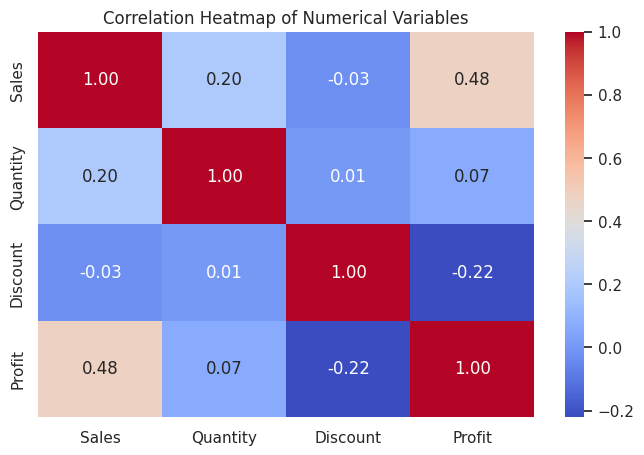

In [23]:
# I am converting the correlation matrix into a heatmap
# so that relationships between numerical variables
# can be understood visually.

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

#Observation:
I used the correlation heatmap to understand the relationships among the numerical variables. The heatmap helps me identify which variables have stronger positive or negative relationships and which variables have relatively weak relationships. I will use these relationships to decide which variables need further investigation

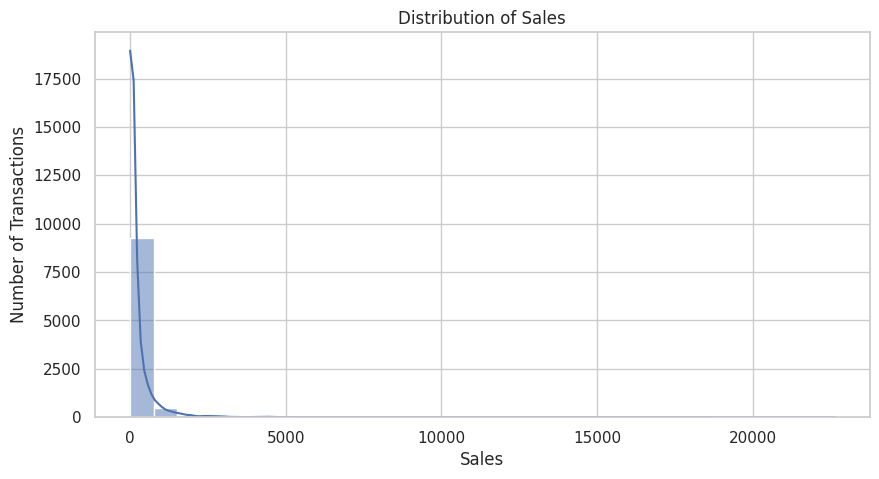

In [24]:
# I want to understand how Sales values are distributed.
# A histogram is useful here because it shows how frequently
# different ranges of Sales occur.

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Sales',
    bins=30,
    kde=True
)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Number of Transactions')

plt.show()

### Observation

I used a histogram to understand how Sales are distributed across the transactions. Most transactions are concentrated at the lower Sales values, while only a small number of transactions have very high Sales values. This creates a right-skewed distribution and is consistent with the difference between the mean Sales (230.15) and median Sales (54.82). This suggests that a few high-value transactions are increasing the overall average Sales.

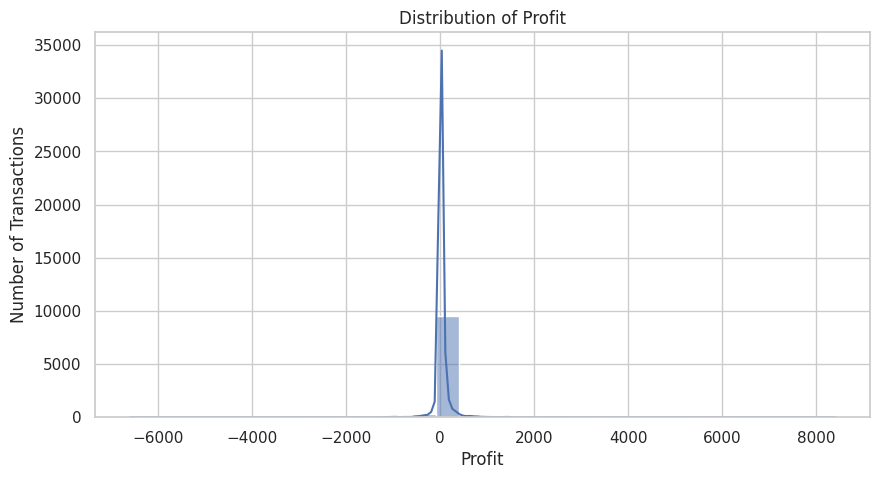

In [25]:
# I want to understand the distribution of Profit.
# This is important because the dataset contains both
# profitable and loss-making transactions.

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Profit',
    bins=30,
    kde=True
)

plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Number of Transactions')

plt.show()

### Observation

The Profit distribution is highly concentrated around zero, with most transactions having relatively small profit values. The distribution also extends toward both negative and positive values, showing that the dataset contains both loss-making and profitable transactions. A small number of transactions have very large negative or positive profit values, which suggests the presence of extreme observations that should be investigated further using a boxplot.

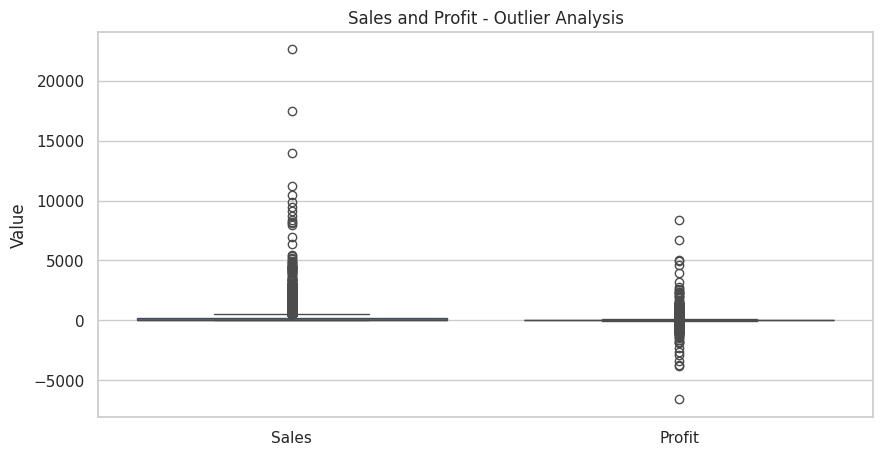

In [26]:
# I am using boxplots to identify unusually high or low values.
# A boxplot helps me visually inspect the spread of the data
# and potential statistical outliers.

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df[['Sales', 'Profit']]
)

plt.title('Sales and Profit - Outlier Analysis')
plt.ylabel('Value')

plt.show()

In [28]:
# I am grouping the data by Category and adding the Sales values.
# This allows me to compare total sales across product categories.

category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741306.3133
Office Supplies,718735.2440


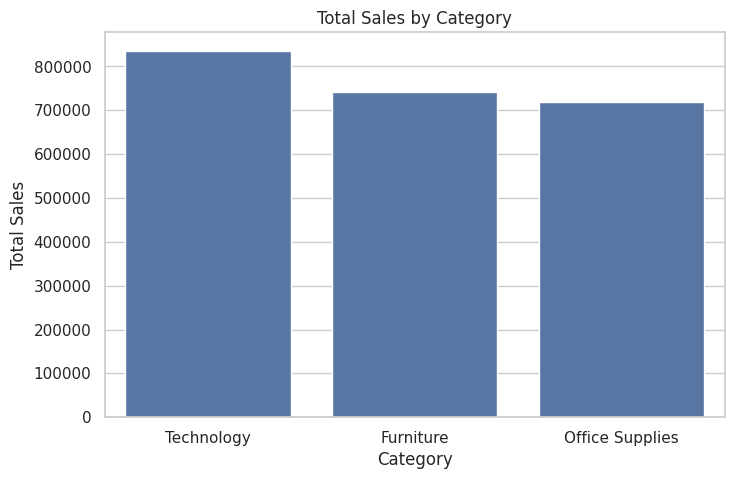

In [29]:
# I am creating a bar chart because I want to compare
# total Sales across a small number of categories.

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

In [30]:
# I am grouping the dataset by Region and calculating
# the total Profit for each region.
# This helps me compare regional profitability.

region_profit = (
    df.groupby('Region')['Profit']
      .sum()
      .sort_values(ascending=False)
)

region_profit

,Profit
Region,
West,108329.8079
East,91506.3092
South,46749.4303
Central,39655.8752


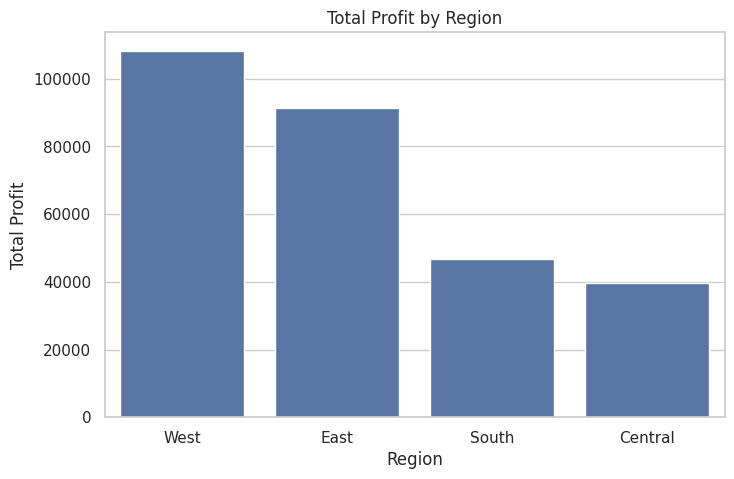

In [31]:
# I am using a bar chart because I want to compare
# profitability across the different regions.

plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_profit.index,
    y=region_profit.values
)

plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')

plt.show()

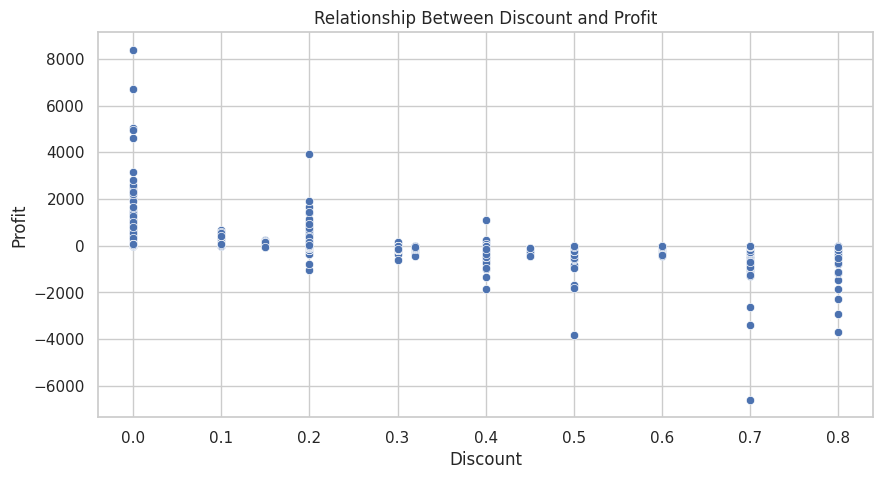

In [32]:
# I want to investigate whether Discount and Profit
# appear to have a relationship.
# A scatter plot is useful because it shows individual
# observations for two numerical variables.

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title('Relationship Between Discount and Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

In [33]:
# I am calculating the correlation between Discount and Profit
# to support the visual observation from the scatter plot.

discount_profit_corr = df['Discount'].corr(df['Profit'])

discount_profit_corr

np.float64(-0.21966206449082396)

In [34]:
# I am checking whether a date column is available.
# A time-series analysis requires a valid date variable.

df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

### Note on Time-Series Analysis

I checked the available columns before performing time-based analysis. The cleaned dataset does not contain a date or time column, so a genuine time-series trend cannot be analyzed using this version of the dataset.

Rather than creating or assuming dates that are not present in the data, I continued the EDA using the available numerical and categorical variables.

In [35]:
# I am generating summary statistics for the numerical columns.
# This helps me understand the typical values, spread,
# minimum values, and maximum values before creating visualizations.

df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [36]:
# I am focusing on the main business-related numerical variables.
# Postal Code is numeric in the dataset, but it represents a location,
# so I will focus my statistical analysis on Sales, Quantity,
# Discount, and Profit.

numeric_columns = ['Sales', 'Quantity', 'Discount', 'Profit']

df[numeric_columns].describe()

,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.00000
mean,230.148902,3.790719,0.156278,28.69013
std,623.721409,2.226657,0.206455,234.45784
min,0.444000,1.000000,0.000000,-6599.97800
25%,17.300000,2.000000,0.000000,1.72620
50%,54.816000,3.000000,0.200000,8.67100
75%,209.970000,5.000000,0.200000,29.37200
max,22638.480000,14.000000,0.800000,8399.97600


### Observation

I used summary statistics to get an initial understanding of the numerical variables before creating visualizations. The dataset contains 9,977 records for each of the selected variables. Sales has a mean of about 230.15, while the median is about 54.82, which suggests that some high-value transactions may be increasing the average. Profit also shows a large spread, with values ranging from approximately -6,599.98 to 8,399.98. These differences indicate that Sales and Profit may contain extreme values, so I will investigate them further using distributions and boxplots.

# Top 3 Insights

### 1. Sales are highly concentrated at lower values

Most transactions have relatively low Sales values, while a small number of transactions have very high Sales. The difference between the mean Sales (230.15) and median Sales (54.82) also supports this finding. This indicates that a few high-value transactions have a strong effect on the overall average Sales.

### 2. Technology is the highest-selling category

Technology generated the highest total Sales among the three product categories, followed by Furniture and Office Supplies. This indicates that Technology is an important contributor to the overall sales performance of the Superstore dataset.

### 3. Discount has a weak negative relationship with Profit

The correlation between Discount and Profit is approximately -0.22, indicating a weak negative relationship. This suggests that higher discounts are associated with lower Profit to some extent. However, correlation does not prove that higher discounts directly cause lower profits.

# Conclusion

In this exploratory data analysis, I analyzed the cleaned Superstore dataset to understand its structure, distributions, relationships, and important business patterns.

I used summary statistics, correlation analysis, histograms, boxplots, bar charts, and a scatter plot to explore the data. The analysis showed that Sales are highly concentrated at lower values, while a small number of transactions have very high Sales. The analysis also showed differences in Sales across product categories and differences in Profit across regions.

The correlation analysis found a weak negative relationship between Discount and Profit. The boxplot analysis also identified extreme Sales and Profit values that require further investigation rather than being automatically treated as data errors.

The dataset does not contain a date column, so a genuine time-series analysis could not be performed. Instead, I focused the EDA on the numerical and categorical variables available in the cleaned dataset.

Overall, this analysis helped me understand the major patterns, relationships, and potential outliers in the dataset before drawing further conclusions.